# Exercise 3
### Big Bang nucleosynthesis

1-4) In order to calculate the primordial nucleosynthesis, the thermodynamic evolution has to be known. Complete the following script by replacing all instances of \'___\' to create a file containing the thermodynamic properties after the Big Bang:

In [1]:
# First import the basic packages
import numpy as np
import matplotlib.pyplot as plt


# Weak freezeout temperature in MeV
kB_Tweak = 0.8

# Photon to baryon ratio
eta = 6.11e-10

# Create a function for the temperature in dependence of the time
T9 = lambda t: 13.336/(np.sqrt(t))

# Create a function for the density
rho = lambda t: 3.376e4*eta*T9(t)**3

# Calculate the time of weak freezeout.
# Remember that the weak freezeout temperature is given in 
# MeV while T9 is given in GK. The conversion factor between them
# is: 1 MeV -> 11.604519 GK
first_time = 2.064
# Create a time array containing a logarithmic time grid starting from first_time up to 10^5 s.
time = np.logspace(np.log10(first_time), 5, 200)


# Now the only missing ingredient is the electron fraction
# For this define some constants
mn    =  939.5654133 # mass neutron    [ MeV / c**2 ]
mp    =  938.2720813 # mass proton     [ MeV / c**2 ]
Delta = mn - mp      # mass difference [ MeV / c**2 ]

# Followed from Maxwell Boltzmann expression for the chemical potentials
n_p_ratio = np.exp(-Delta/0.8)

# From n+p = 1:
neutron_freezout = n_p_ratio/(1. + n_p_ratio)
proton_freezout  = 1. - neutron_freezout
# The initial electron fraction is therefore given as:
# Same as neutron abundance, because there are only nucleons
ye_freezout = proton_freezout/(neutron_freezout+proton_freezout) 


# Save the trajectory 
out = np.array([time,T9(time),rho(time),[ye_freezout for i in range(len(time))]]).T
np.savetxt('bbn_trajectory.dat',out,header='time[s], T9[GK], density[g/cm^3], Ye \n')

5) Modify the parameter file BigBang.par  in order to calculate the primordial nucleosynthesis with WinNet. For the calculation use the files that are contained in your folder. 
1. net_bbn : List with contained nuclei in the network
2. bbn_winvn : List with properties of the nuclei
3. bbn_reactions : Reaction rates included
4. track_nuclei: Nuclei to be tracked

When the parameter file is ready, run WinNet.

In [31]:
! /home/teaching/WinNet/bin/winnet BigBang.par >OUT 2>ERR

After your calculation plot the abundance of the most abundant nuclei versus time.

3) Create many trajectories for different etas and run all of them with WinNet

In [18]:
# Define an array of etas (consider the interval of etas shown in the plot from the lecture)
etas =np.logspace(-9, -10, 50)

In [28]:
# For every value of eta, create a different trajectory
for eta in etas:
    
    # Modify only the variables depending on eta
    rho = lambda t: 3.376e4*eta*T9(t)**3
    out = [[ti, T9(ti), rho(ti), ye_freezout] for ti in time]
    
    # Save every trajectory with a different name, in a separate folder
    np.savetxt('trajectories/bbn_trajectory'+str(eta)+".dat",out,header='time[s], T9[GK], density[g/cm^3], Ye \n')

In [29]:
# For every value of eta, run the network
for eta in etas:
    
    # Modify the parameter file with the name of the specific trajectory
    
    # Read the parameter file
    with open('BigBang.par','r') as fr:
        lines = fr.readlines()
    
    # Modify the line corresponding to the trajectory name
    lines[22] = 'trajectory_file          = \"trajectories/bbn_trajectory'+str(eta)+'.dat\"\n'
    
    # Write the new parameter file
    with open('BigBang.par','w') as fw:
        fw.writelines(lines)
    
    # Run the network
    !../../WinNet/bin/winnet BigBang.par >OUT 2>ERR
    
    # Store the results with a different name, in a separate folder (in particular we need the final abundances)
    !mv finab.dat results/finab{eta}.dat
    print('Ran network for',eta)

Ran network for 1e-09
Ran network for 9.540954763499925e-10
Ran network for 9.102981779915227e-10
Ran network for 8.68511373751352e-10
Ran network for 8.28642772854686e-10
Ran network for 7.906043210907701e-10
Ran network for 7.543120063354608e-10
Ran network for 7.196856730011529e-10
Ran network for 6.866488450042998e-10
Ran network for 6.551285568595495e-10
Ran network for 6.250551925273976e-10
Ran network for 5.963623316594636e-10
Ran network for 5.689866029018305e-10
Ran network for 5.428675439323859e-10
Ran network for 5.179474679231202e-10
Ran network for 4.941713361323838e-10
Ran network for 4.71486636345739e-10
Ran network for 4.498432668969453e-10
Ran network for 4.2919342601287785e-10
Ran network for 4.0949150623804193e-10
Ran network for 3.9069399370546207e-10
Ran network for 3.727593720314938e-10
Ran network for 3.556480306223136e-10
Ran network for 3.3932217718953296e-10
Ran network for 3.23745754281764e-10
Ran network for 3.088843596477485e-10
Ran network for 2.9470517025

In [19]:
etas

array([1.00000000e-09, 9.54095476e-10, 9.10298178e-10, 8.68511374e-10,
       8.28642773e-10, 7.90604321e-10, 7.54312006e-10, 7.19685673e-10,
       6.86648845e-10, 6.55128557e-10, 6.25055193e-10, 5.96362332e-10,
       5.68986603e-10, 5.42867544e-10, 5.17947468e-10, 4.94171336e-10,
       4.71486636e-10, 4.49843267e-10, 4.29193426e-10, 4.09491506e-10,
       3.90693994e-10, 3.72759372e-10, 3.55648031e-10, 3.39322177e-10,
       3.23745754e-10, 3.08884360e-10, 2.94705170e-10, 2.81176870e-10,
       2.68269580e-10, 2.55954792e-10, 2.44205309e-10, 2.32995181e-10,
       2.22299648e-10, 2.12095089e-10, 2.02358965e-10, 1.93069773e-10,
       1.84206997e-10, 1.75751062e-10, 1.67683294e-10, 1.59985872e-10,
       1.52641797e-10, 1.45634848e-10, 1.38949549e-10, 1.32571137e-10,
       1.26485522e-10, 1.20679264e-10, 1.15139540e-10, 1.09854114e-10,
       1.04811313e-10, 1.00000000e-10])

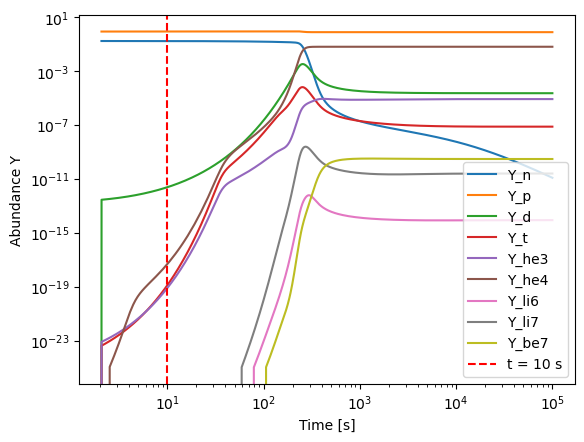

In [8]:
data = np.loadtxt("tracked_nuclei_BEGINN.dat", skiprows=1)

time = data[:, 0]
Y_n = data[:, 1]
Y_p = data[:, 2]
Y_d = data[:, 3]
Y_t = data[:, 4]
Y_he3 = data[:, 5]
Y_he4 = data[:, 6]
Y_li6 = data[:, 7]
Y_li7 = data[:, 8]
Y_be7 = data[:, 9]

abundances = [Y_n, Y_p, Y_d, Y_t, Y_he3, Y_he4, Y_li6, Y_li7, Y_be7]
labels = ['Y_n', 'Y_p', 'Y_d', 'Y_t', 'Y_he3', 'Y_he4', 'Y_li6', 'Y_li7', 'Y_be7']
for i in range(len(abundances)):
    plt.plot(time, abundances[i], label=labels[i])

plt.axvline(x=10, color='red', linestyle='--', label='t = 10 s')
plt.xlabel('Time [s]')
plt.ylabel('Abundance Y')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

After the first 10s, the most abundant species are by far neutrons, protons and a rising abundance of deuterium. At the end of the time interval, protons are still the most abundant species but due to the primordial nucleosynthesis the Helium-4 abundance is quite high.

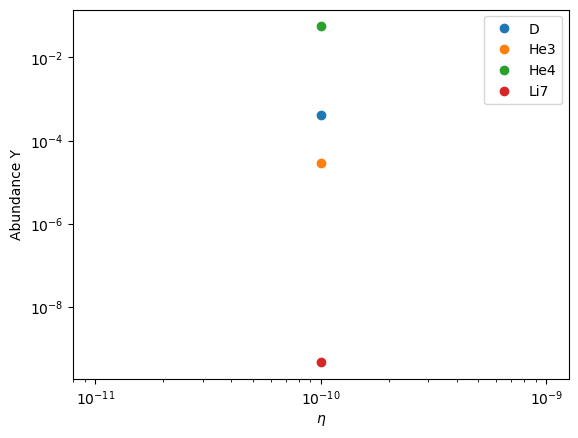

In [17]:
data50 = np.loadtxt('finab(3).dat', comments='#')

A = data50[:, 0]
Z = data50[:, 1]
Yi = data50[:, 3]
D     = Yi[(Z==1) & (A==2)]
He3   = Yi[(Z==2) & (A==3)]
He4   = Yi[(Z==2) & (A==4)]
Li7   = Yi[(Z==3) & (A==7)]

eta = 1e-10

plt.plot(eta, D, 'o', label='D')
plt.plot(eta, He3, 'o', label='He3')
plt.plot(eta, He4, 'o', label='He4')
plt.plot(eta, Li7, 'o', label='Li7')

plt.xscale('log')
plt.yscale('log') 
plt.xlabel('$\eta$')
plt.ylabel('Abundance Y')
plt.legend()
plt.show()

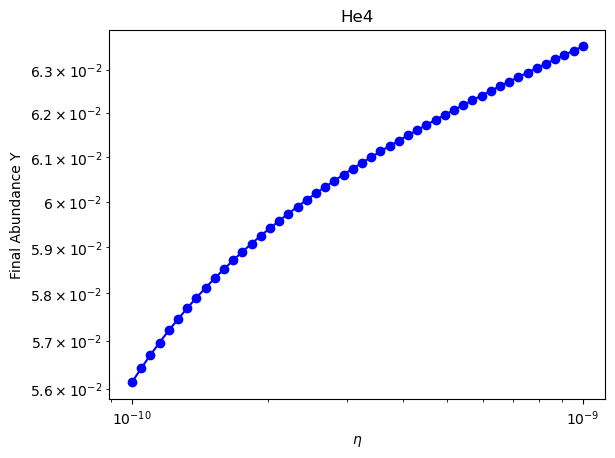

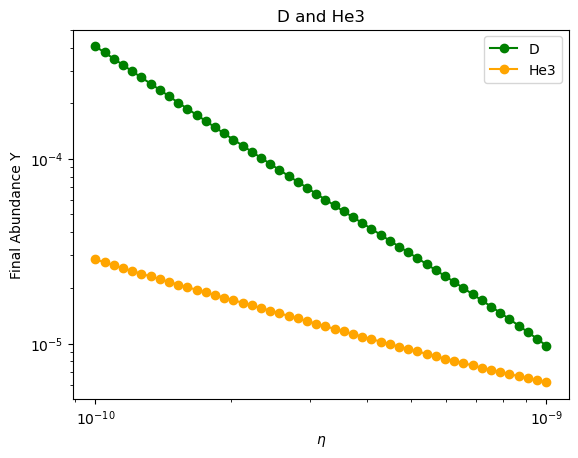

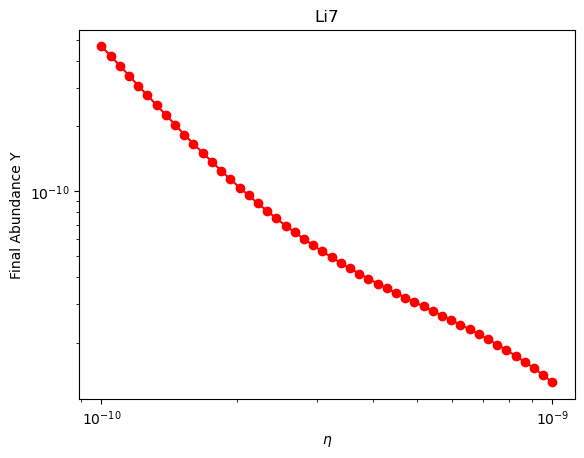

In [32]:
D_vals, He3_vals, He4_vals, Li7_vals = [], [], [], []

for eta in etas:
    filename = f'finab{eta}.dat'
    data = np.loadtxt(filename, comments='#')
    
    A = data[:, 0]
    Z = data[:, 1]
    Yi = data[:, 3]
    
    D_vals.append(Yi[(Z==1) & (A==2)][0])
    He3_vals.append(Yi[(Z==2) & (A==3)][0])
    He4_vals.append(Yi[(Z==2) & (A==4)][0])
    Li7_vals.append(Yi[(Z==3) & (A==7)][0])

D_vals = np.array(D_vals)
He3_vals = np.array(He3_vals)
He4_vals = np.array(He4_vals)
Li7_vals = np.array(Li7_vals)

plt.figure()
plt.plot(etas, He4_vals, 'o-', label='He4', color='blue')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel('Final Abundance Y')
plt.title('He4')
plt.show()

plt.figure()
plt.plot(etas, D_vals, 'o-', label='D', color='green')
plt.plot(etas, He3_vals, 'o-', label='He3', color='orange')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel('Final Abundance Y')
plt.title('D and He3')
plt.legend()
plt.show()

plt.figure()
plt.plot(etas, Li7_vals, 'o-', label='Li7', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\eta$')
plt.ylabel('Final Abundance Y')
plt.title('Li7')
plt.show()

The resulting plots of the final abundances versus the different $\eta$ values looks similar in case of He-4, He-3 and Deuterium in terms of shape. In the case of Li-7 the curve is starting off good but the minimum could not be reproduced. The reason for that could be the small $\eta$ range we used, meaning that the minimum is either at significantly higher or lower values.